# Clustering Project

**Deadline for submission: 17/3/2026 @ 11:59 PM**


Please make sure to explain your work using comments whenever possible.

**Objective:**
The objective of this project is to teach students how to apply clustering to real datasets.

You should be able to answer the following questions and provide reasonable justification for your answers:
* Which clustering approach have you decided to use on each dataset?
* Compare between Kmeans, Hierarchal and DBScan.
* Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?
* What is the effect of different distance functions on the calculated clusters?
* How did you evaluate the performance of different clustering techniques on different datatsets?
* Visualize your output where applicable.
* What is the effect of scaling on the performance of clustering techniques?






Running this project requires the following imports:

In [1]:
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn.preprocessing as prep
from sklearn.datasets import make_blobs
from plotnine import *
# StandardScaler is a function to normalize the data
# You may also check MinMaxScaler and MaxAbsScaler
#from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN


from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

%matplotlib inline
# Please refer to the sklearn documentation to learn more about the different parameters for each clustering technique.

In [2]:
# helper function that allows us to display data in 2 dimensions an highlights the clusters
def display_cluster(X,km=[],num_clusters=0):
    color = 'brgcmyk'  #List colors
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0],X[:,1],c = color[0],alpha = alpha,s = s)
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_==i,0],X[km.labels_==i,1],c = color[i],alpha = alpha,s=s)
            plt.scatter(km.cluster_centers_[i][0],km.cluster_centers_[i][1],c = color[i], marker = 'x', s = 100)

## Multi Blob Data Set
* The dataset generated below is known to be best clustered into 6 clusters.
* Cluster the data set below using the three different clustering techniques discussed in the course.
* Visualize your clustering output in each step of your work.



(1450, 2)


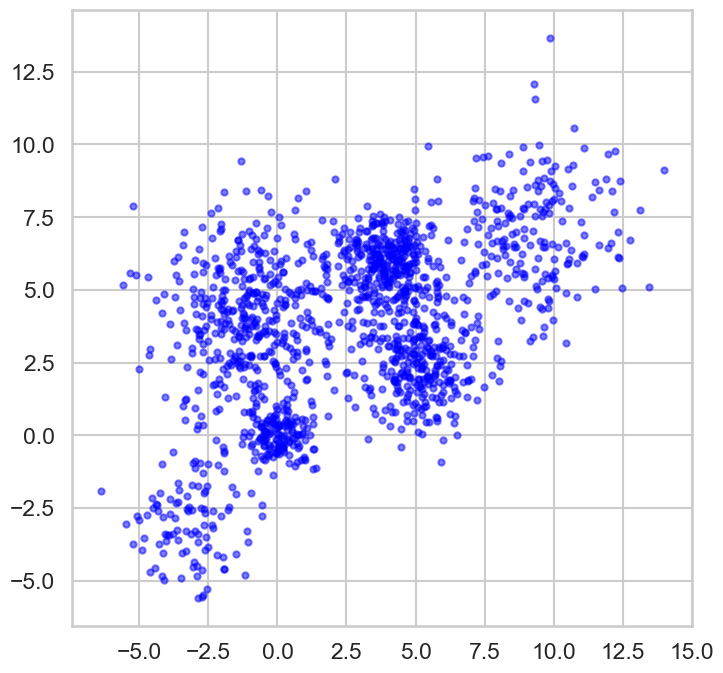

In [3]:
#Data Generation and Visualization
plt.rcParams['figure.figsize'] = [8,8]
sns.set_style("whitegrid")
sns.set_context("talk")

n_bins = 6
centers = [(-3, -3), (0, 0), (5,2.5),(-1, 4), (4, 6), (9,7)]
Multi_blob_Data, y = make_blobs(n_samples=[100,150, 300, 400,300, 200], n_features=2, cluster_std=[1.3,0.6, 1.2, 1.7,0.9,1.7],
                  centers=centers, shuffle=False, random_state=42)
display_cluster(Multi_blob_Data)
print(Multi_blob_Data.shape)


In [4]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(Multi_blob_Data)


### Kmeans
* Use Kmeans with different values of K to cluster the above data.
* Display the outcome of each value of K.
* Plot distortion function versus K and choose the approriate value of K.
* Plot the silhouette_score versus K and use it to choose the best K.
* Store the silhouette_score for the best K for later comparison with other clustering techniques.
* Comment on the effect of centroid initialization on cluster assignment.
* Hint: Lookup k-means++ .

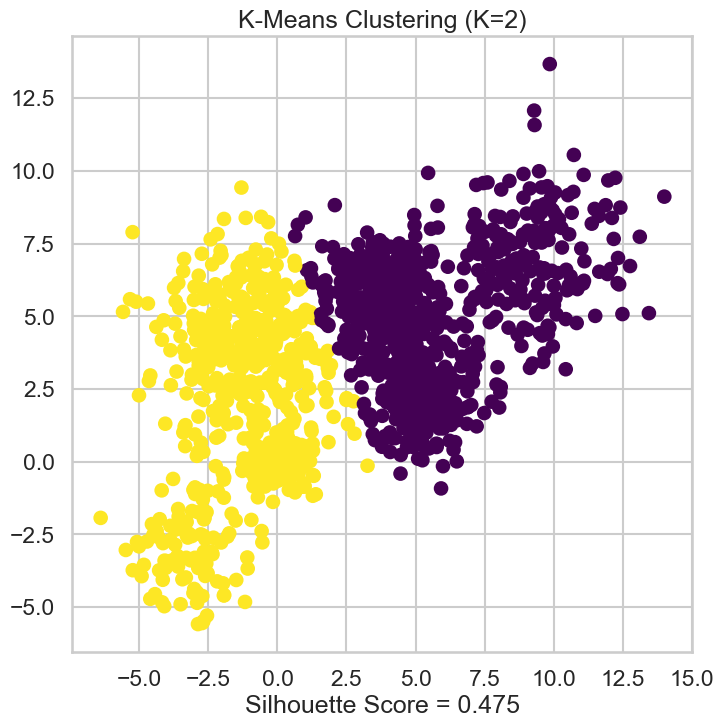

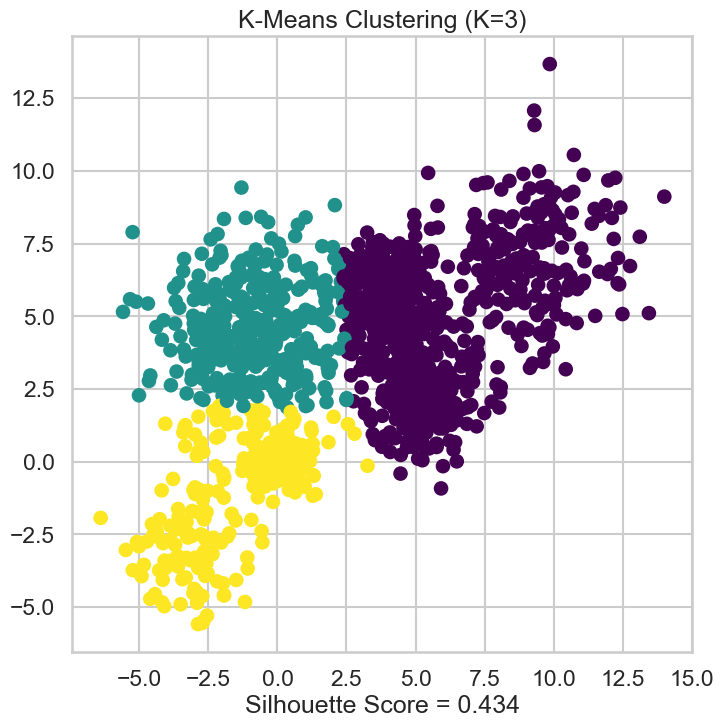

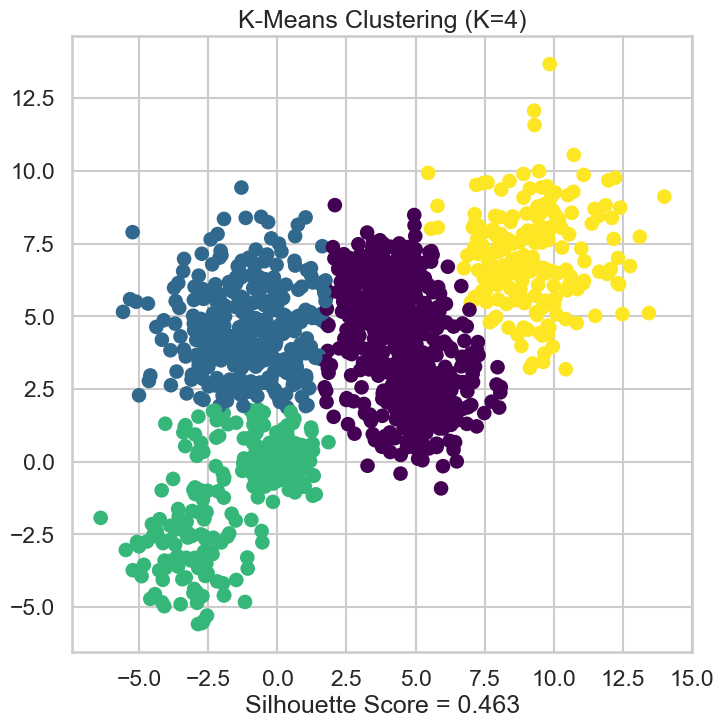

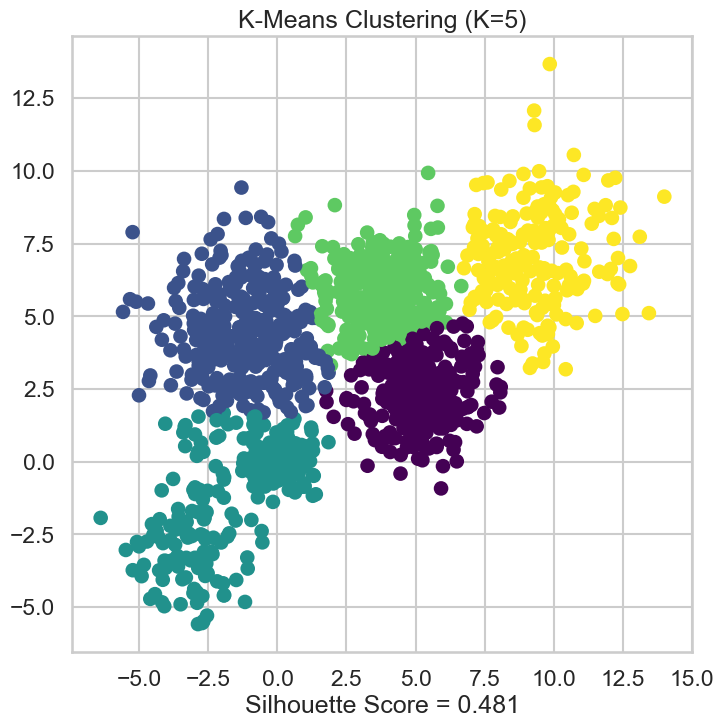

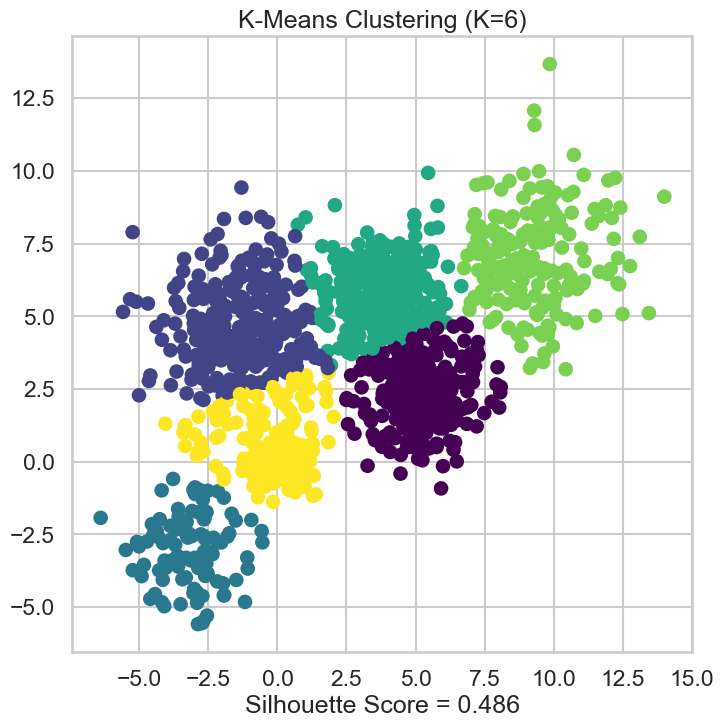

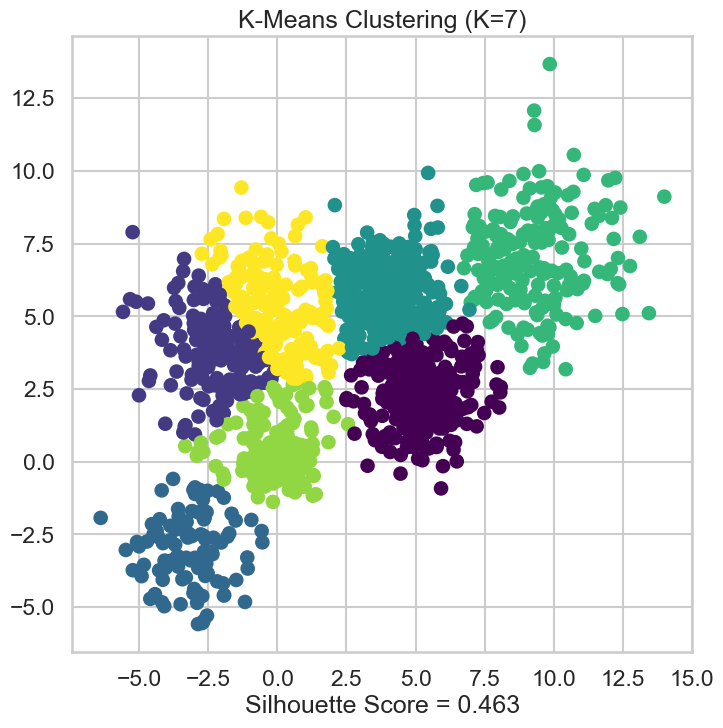

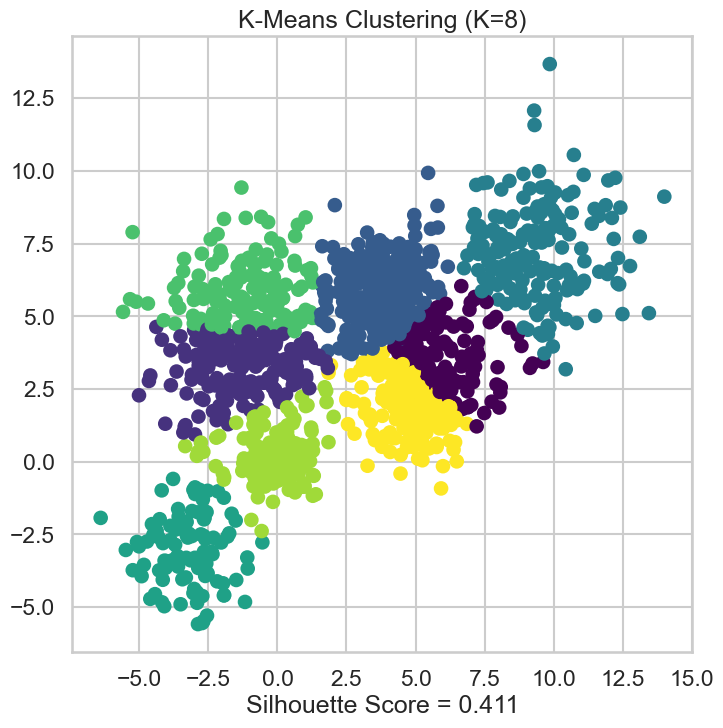

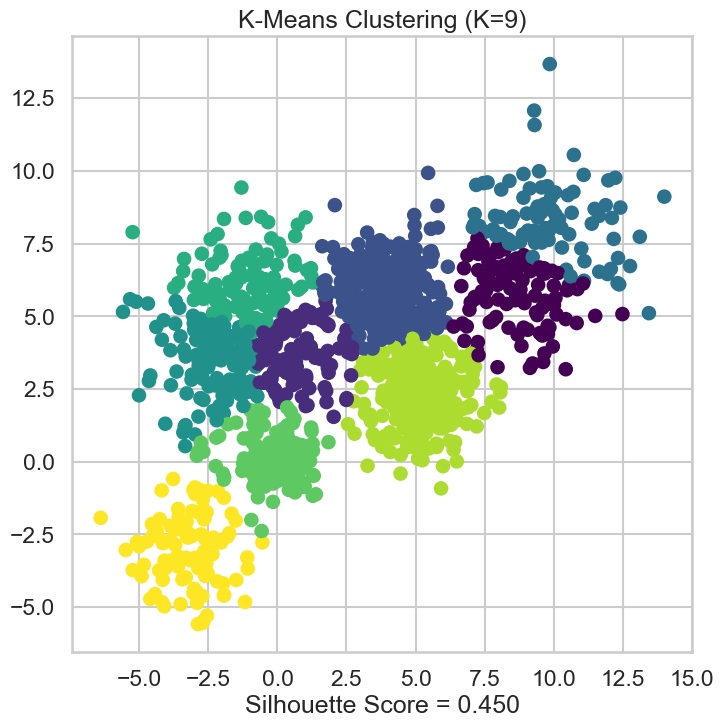

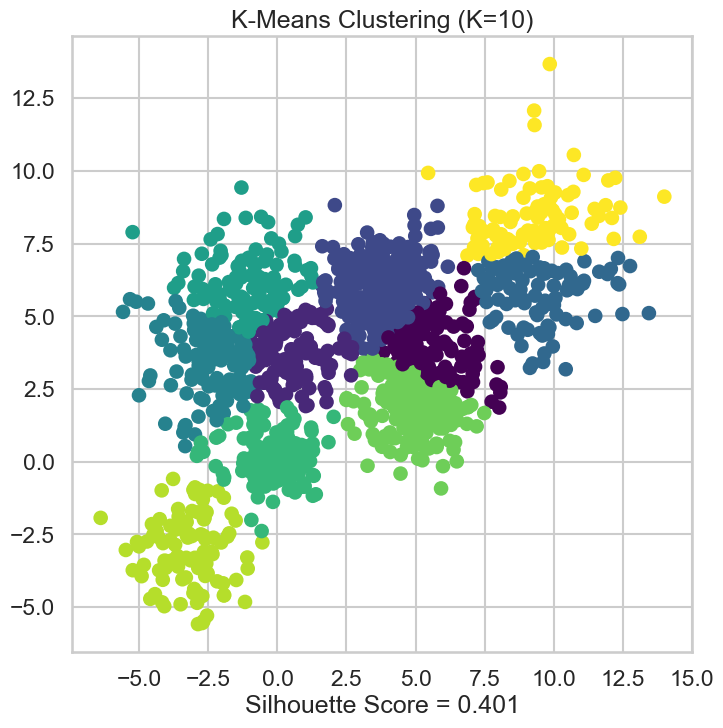

Best K according to Silhouette Score: 6
Best Silhouette Score: 0.4862240839323367


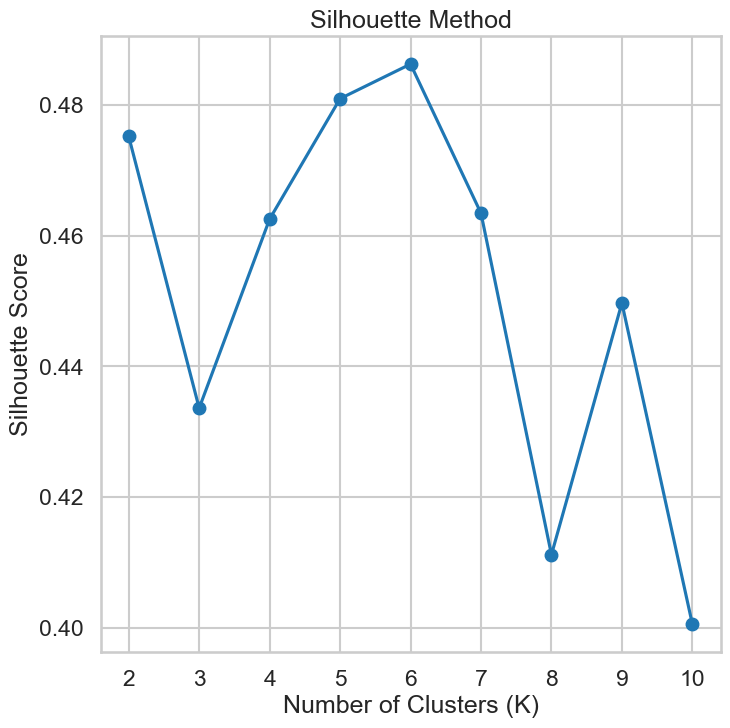

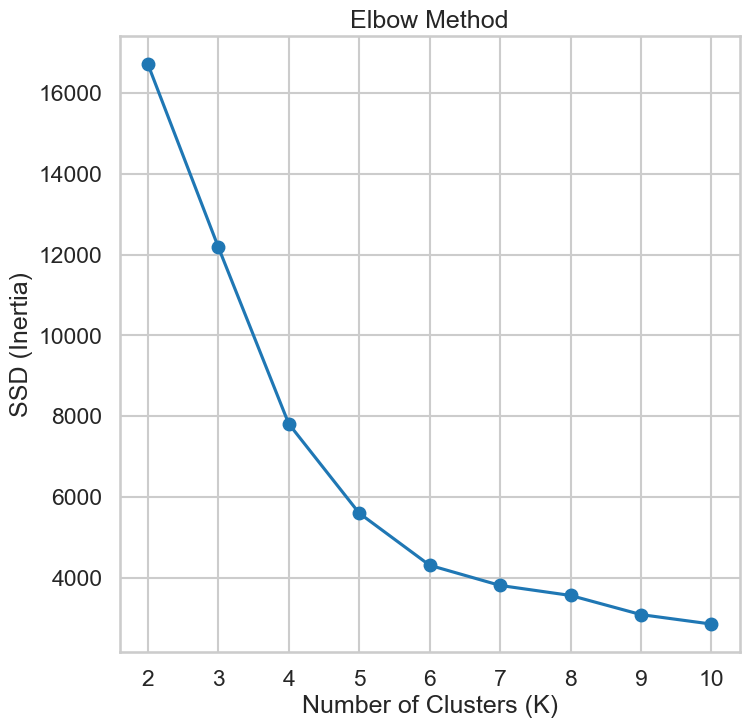

Recommended number of clusters according to the Elbow Method: 3


In [5]:
#Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ssd = []
sil_scores = []
K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k,init='k-means++', random_state=42)
    labels= kmeans.fit_predict(Multi_blob_Data)
    score = silhouette_score(Multi_blob_Data, labels)

    sil_scores.append(score)
    ssd.append(kmeans.inertia_)

    # Display clustering result
    plt.figure()
    plt.scatter(Multi_blob_Data[:,0], Multi_blob_Data[:,1], c=labels, cmap='viridis')
    plt.title(f"K-Means Clustering (K={k})")
    # print silhouette score under the plot
    plt.xlabel(f"Silhouette Score = {score:.3f}")       
    plt.show()

# Computing the rate of change
diffs = np.diff(ssd)

#Choose the best k
best_k = K_range[np.argmax(sil_scores)]
#Store the silhouette score
best_kmeans_silhouette = max(sil_scores)

print("Best K according to Silhouette Score:", best_k)
print("Best Silhouette Score:", best_kmeans_silhouette)

# Silhouette Score Plot
plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

# Detect elbow as the largest drop in SSD
elbow_index = np.argmax(np.abs(diffs)) + 1
recommended_k = K_range[elbow_index]

# plot
plt.plot(K_range, ssd, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSD (Inertia)")
plt.title("Elbow Method")
plt.show()

print(f"Recommended number of clusters according to the Elbow Method: {recommended_k}") 

# Observations : True clusters: 6
# Elbow merges some clusters → suggests 3
# Silhouette detects separation → suggests 6


### Hierarchal Clustering
* Use AgglomerativeClustering function to  to cluster the above data.
* In the  AgglomerativeClustering change the following parameters:
    * Affinity (use euclidean, manhattan and cosine)
    * Linkage(try different options)
    * Distance_threshold (try different options)
* Plot the dendrograph for one trial.
* For each of these trials, calculate the silhouette_score and display the resulting clusters.  
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observation.

Metric: euclidean | Linkage: single | Threshold: 1 | Silhouette: -0.149
Metric: euclidean | Linkage: single | Threshold: 2 | Silhouette: 0.322
Metric: manhattan | Linkage: single | Threshold: 2 | Silhouette: 0.149
Metric: cosine | Linkage: complete | Threshold: 0.5 | Silhouette: 0.111
Metric: cosine | Linkage: complete | Threshold: 1 | Silhouette: 0.189
Metric: cosine | Linkage: average | Threshold: 0.2 | Silhouette: 0.204
Metric: cosine | Linkage: average | Threshold: 0.5 | Silhouette: 0.280
Metric: cosine | Linkage: average | Threshold: 1 | Silhouette: 0.353

Best Agglomerative Configuration
Best Silhouette Score: 0.353
Metric: cosine
Linkage: average
Distance Threshold: 1


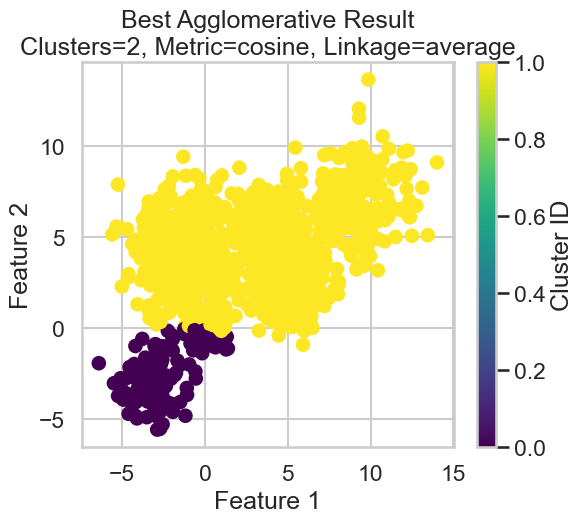

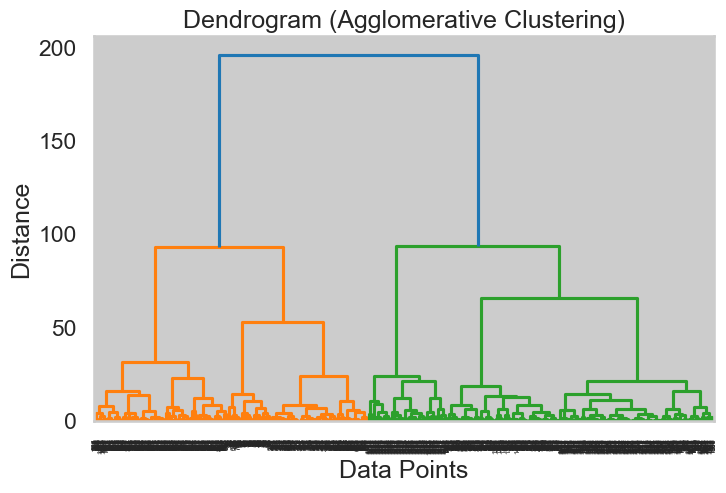

In [6]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

# Parameters to test
metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']
distance_thresholds = [0.2, 0.5, 1, 2, 3]

best_score = -1
best_params = None
best_labels = None

results = []

for metric in metrics:
    for link in linkages:

        # Ward only works with Euclidean
        if link == 'ward' and metric != 'euclidean':
            continue

        for threshold in distance_thresholds:

            model = AgglomerativeClustering(
                n_clusters=None,
                metric=metric,
                linkage=link,
                distance_threshold=threshold
            )

            labels = model.fit_predict(Multi_blob_Data)

            # Need at least 2 clusters for silhouette score
            num_clusters = len(np.unique(labels))

            if num_clusters < 2 or num_clusters > 10:
                continue

            score = silhouette_score(Multi_blob_Data, labels)

            print(f"Metric: {metric} | Linkage: {link} | Threshold: {threshold} | Silhouette: {score:.3f}")

            results.append((metric, link, threshold, score))

            if score > best_score:
                best_score = score
                best_params = (metric, link, threshold)
                best_labels = labels


# Number of clusters found
n_clusters = len(np.unique(best_labels))

print("\nBest Agglomerative Configuration")
print(f"Best Silhouette Score: {best_score:.3f}")
print(f"Metric: {best_params[0]}")
print(f"Linkage: {best_params[1]}")
print(f"Distance Threshold: {best_params[2]}")


# Plot best clustering result
plt.figure(figsize=(6,5))
scatter=plt.scatter(Multi_blob_Data[:,0], Multi_blob_Data[:,1],
            c=best_labels, cmap='viridis')

plt.title(
    f"Best Agglomerative Result\n"
    f"Clusters={n_clusters}, Metric={best_params[0]}, Linkage={best_params[1]}"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.colorbar(scatter, label="Cluster ID")

plt.show()


# -------------------------------------------------
# Plot Dendrogram for one trial
# -------------------------------------------------

linked = linkage(Multi_blob_Data, method='ward')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title("Dendrogram (Agglomerative Clustering)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

### DBScan
* Use DBScan function to  to cluster the above data.
* In the  DBscan change the following parameters:
    * EPS (from 0.1 to 3)
    * Min_samples (from 5 to 25)

* Plot the silhouette_score versus the variation in the EPS and the min_samples.
* Plot the resulting Clusters in this case.
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observations and comments.

EPS=0.10 | Min_samples=5 | Clusters=11 | Noise=1380 | Silhouette=0.689
EPS=0.10 | Min_samples=6 | Clusters=4 | Noise=1425 | Silhouette=0.915
EPS=0.20 | Min_samples=5 | Clusters=38 | Noise=916 | Silhouette=0.280
EPS=0.20 | Min_samples=6 | Clusters=22 | Noise=1053 | Silhouette=0.350
EPS=0.20 | Min_samples=7 | Clusters=16 | Noise=1151 | Silhouette=0.365
EPS=0.20 | Min_samples=8 | Clusters=12 | Noise=1231 | Silhouette=0.361
EPS=0.20 | Min_samples=9 | Clusters=9 | Noise=1267 | Silhouette=0.492
EPS=0.20 | Min_samples=10 | Clusters=7 | Noise=1311 | Silhouette=0.578
EPS=0.20 | Min_samples=11 | Clusters=8 | Noise=1327 | Silhouette=0.620
EPS=0.20 | Min_samples=12 | Clusters=3 | Noise=1402 | Silhouette=0.879
EPS=0.20 | Min_samples=13 | Clusters=3 | Noise=1405 | Silhouette=0.890
EPS=0.30 | Min_samples=5 | Clusters=37 | Noise=481 | Silhouette=0.208
EPS=0.30 | Min_samples=6 | Clusters=26 | Noise=626 | Silhouette=0.228
EPS=0.30 | Min_samples=7 | Clusters=20 | Noise=740 | Silhouette=0.203
EPS=0.30 | M

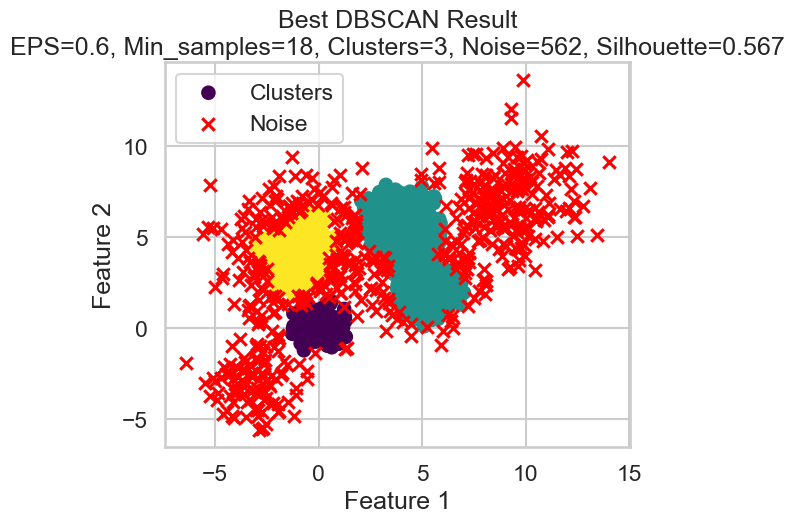

In [7]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# Parameter ranges
eps_values = np.arange(0.1, 3.1, 0.1)
min_samples_values = range(5, 26)

best_score = -1
best_params = None
best_labels = None
best_clusters = None
best_noise = None

results = []

# --------------------------------------------------
# Parameter Search
# --------------------------------------------------

for eps in eps_values:
    for min_s in min_samples_values:

        db = DBSCAN(eps=eps, min_samples=min_s)

        labels = db.fit_predict(Multi_blob_Data)

        # Count clusters excluding noise
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Silhouette requires at least 2 clusters
        if n_clusters > 1:

            # Remove noise points
            mask = labels != -1
            filtered_data = Multi_blob_Data[mask]
            filtered_labels = labels[mask]

            if len(set(filtered_labels)) > 1:

                score = silhouette_score(filtered_data, filtered_labels)

                print(f"EPS={eps:.2f} | Min_samples={min_s} | Clusters={n_clusters} | Noise={n_noise} | Silhouette={score:.3f}")

                results.append((eps, min_s, score))

                # Store best result
                noise_ratio = n_noise / len(Multi_blob_Data)

                if score > best_score and noise_ratio < 0.4:
                    best_score = score
                    best_params = (eps, min_s)
                    best_labels = labels
                    best_clusters = n_clusters
                    best_noise = n_noise

            else:
                results.append((eps, min_s, np.nan))

        else:
            results.append((eps, min_s, np.nan))


# --------------------------------------------------
# Best Configuration
# --------------------------------------------------

print("\nBest DBSCAN Configuration")
print(f"Best Silhouette Score: {best_score:.3f}")
print(f"Best EPS: {best_params[0]}")
print(f"Best Min_samples: {best_params[1]}")
print(f"Clusters Found: {best_clusters}")


# Plot Best DBSCAN Clustering (show noise separately)

if best_labels is not None:

    plt.figure(figsize=(6,5))

    # Normal clusters
    core_mask = best_labels != -1
    plt.scatter(
        Multi_blob_Data[core_mask,0],
        Multi_blob_Data[core_mask,1],
        c=best_labels[core_mask],
        cmap='viridis',
        label="Clusters"
    )

    # Noise points
    noise_mask = best_labels == -1
    plt.scatter(
        Multi_blob_Data[noise_mask,0],
        Multi_blob_Data[noise_mask,1],
        c='red',
        marker='x',
        label="Noise"
    )

    plt.title(
        f"Best DBSCAN Result\n"
        f"EPS={best_params[0]}, Min_samples={best_params[1]}, "
        f"Clusters={best_clusters}, Noise={best_noise}, "
        f"Silhouette={best_score:.3f}"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.legend()

    plt.show()

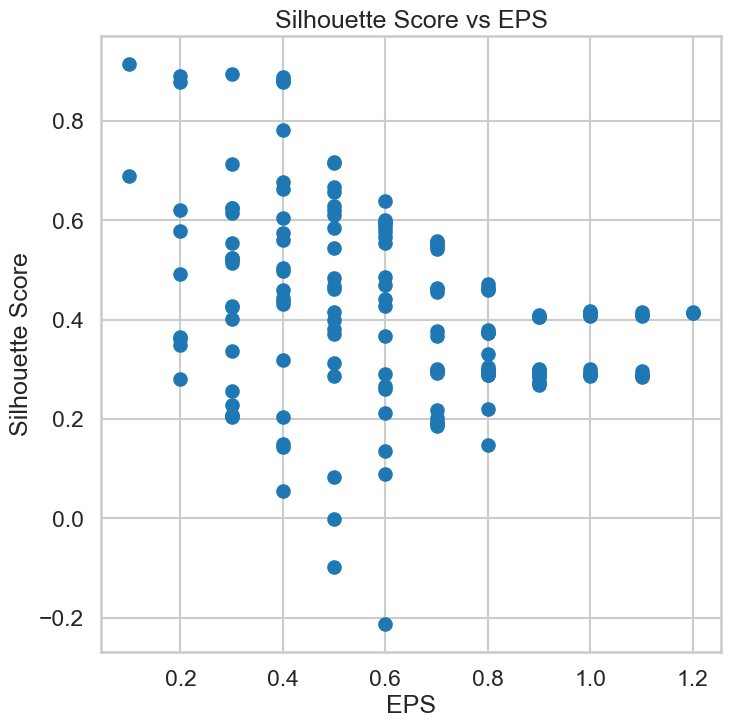

In [8]:
# Silhouette vs EPS
# Shows how cluster quality changes as neighborhood radius increases.

eps_plot = [r[0] for r in results if not np.isnan(r[2])]
score_plot = [r[2] for r in results if not np.isnan(r[2])]

plt.figure()
plt.scatter(eps_plot, score_plot)
plt.xlabel("EPS")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs EPS")
plt.show()


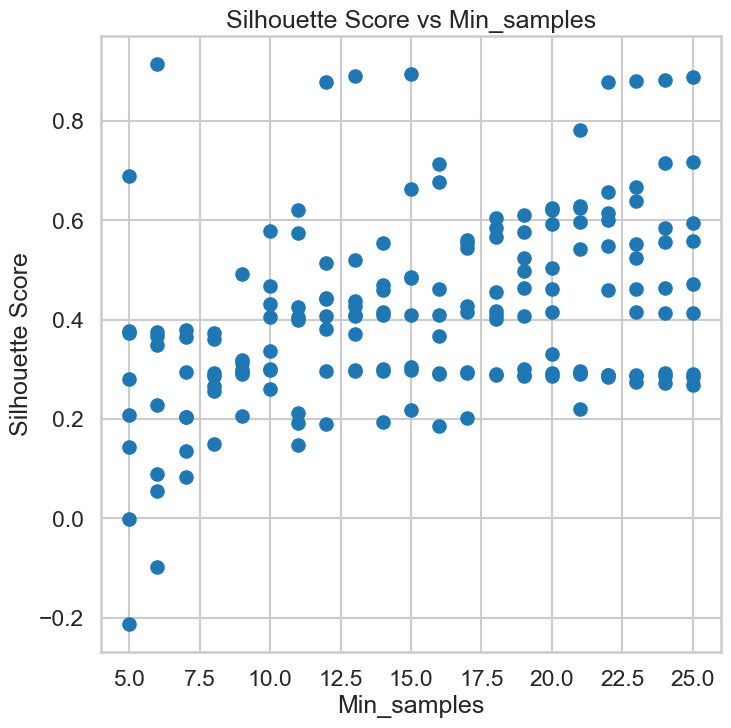

In [9]:
# Silhouette vs Min_samples
# Shows how cluster density requirement affects clusters.

min_samples_plot = [r[1] for r in results if not np.isnan(r[2])]

plt.figure()
plt.scatter(min_samples_plot, score_plot)
plt.xlabel("Min_samples")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Min_samples")
plt.show()

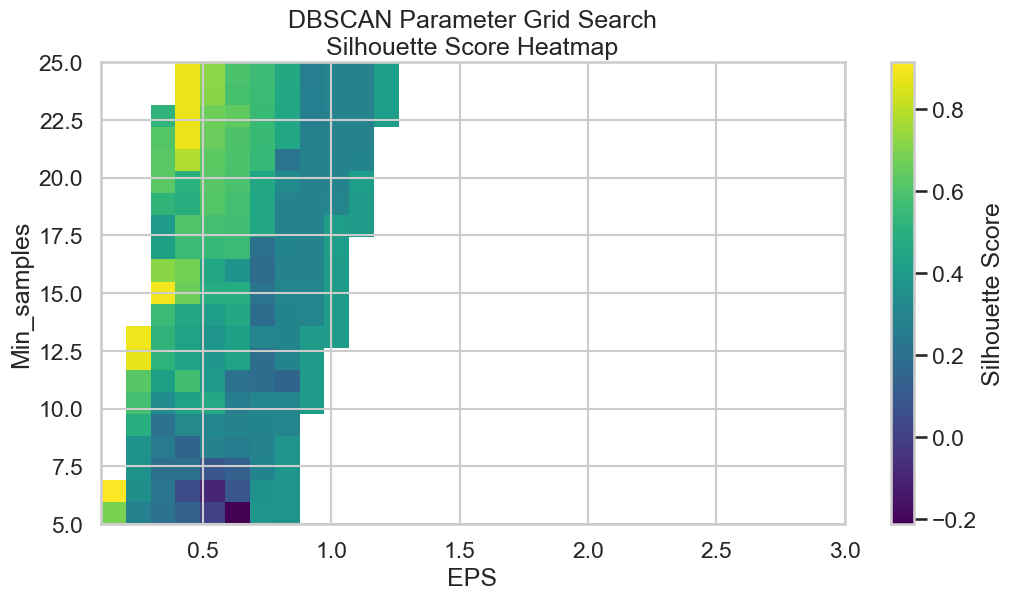

In [10]:
# Heatmap of Silhouette Scores

# Create grid for heatmap
heatmap = np.full((len(min_samples_values), len(eps_values)), np.nan)

for eps, min_s, score in results:
    
    if not np.isnan(score):
        
        eps_index = np.where(eps_values == eps)[0][0]
        min_index = min_s - min_samples_values.start
        
        heatmap[min_index, eps_index] = score


plt.figure(figsize=(12,6))

plt.imshow(
    heatmap,
    aspect='auto',
    origin='lower',
    cmap='viridis',
    extent=[eps_values.min(), eps_values.max(),
            min_samples_values.start, min_samples_values.stop-1]
)

plt.colorbar(label="Silhouette Score")

plt.xlabel("EPS")
plt.ylabel("Min_samples")

plt.title("DBSCAN Parameter Grid Search\nSilhouette Score Heatmap")

plt.show()

## iris data set
The iris data set is test data set that is part of the Sklearn module
which contains 150 records each with 4 features. All the features are represented by real numbers.

The data represents three classes.


In [11]:
from sklearn.datasets import load_iris
iris_data = load_iris()
iris_data.target[[10, 25, 50]]
#array([0, 0, 1])
list(iris_data.target_names)
['setosa', 'versicolor', 'virginica']

# Dara Praparation
from sklearn.preprocessing import StandardScaler
X = iris_data.data
y = iris_data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


K = 2 | Silhouette Score = 0.582
K = 3 | Silhouette Score = 0.460
K = 4 | Silhouette Score = 0.387
K = 5 | Silhouette Score = 0.346
K = 6 | Silhouette Score = 0.317
K = 7 | Silhouette Score = 0.320
K = 8 | Silhouette Score = 0.339
K = 9 | Silhouette Score = 0.342
K = 10 | Silhouette Score = 0.352

Best KMeans Result
Best K: 2
Best Silhouette Score: 0.5817500491982808


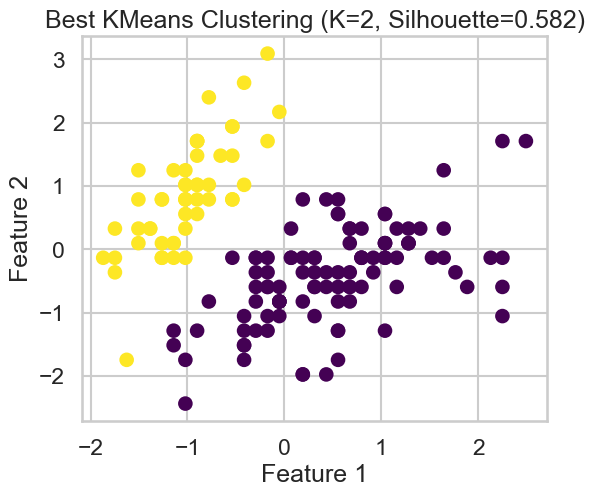

In [12]:
# KMeans Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

best_score = -1
best_k = None
best_labels = None
best_model = None

# Search for best number of clusters
for k in range(2, 11):
    
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    print(f"K = {k} | Silhouette Score = {score:.3f}")
    
    if score > best_score:
        best_score = score
        best_k = k
        best_labels = labels
        best_model = model


print("\nBest KMeans Result")
print("Best K:", best_k)
print("Best Silhouette Score:", best_score)

best_kmeans_silhouette = best_score


# -------------------------------
# Plot Best Clustering
# -------------------------------

plt.figure(figsize=(6,5))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=best_labels,
    cmap='viridis'
)

plt.title(f"Best KMeans Clustering (K={best_k}, Silhouette={best_score:.3f})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

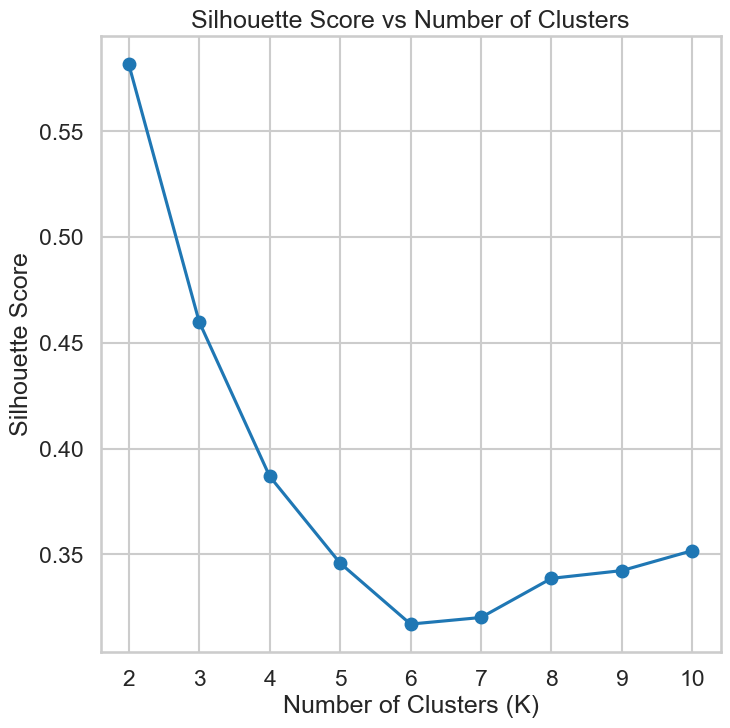

In [13]:
# proving why the chosen K is best
 
k_values = []
scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    
    k_values.append(k)
    scores.append(score)

plt.plot(k_values, scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

EPS=0.30 | Min_samples=5 | Clusters=3 | Noise=120 | Silhouette=0.630
EPS=0.30 | Min_samples=6 | Clusters=2 | Noise=129 | Silhouette=0.628
EPS=0.30 | Min_samples=7 | Clusters=2 | Noise=129 | Silhouette=0.628
EPS=0.30 | Min_samples=8 | Clusters=2 | Noise=131 | Silhouette=0.639
EPS=0.50 | Min_samples=5 | Clusters=2 | Noise=34 | Silhouette=0.656
EPS=0.50 | Min_samples=6 | Clusters=4 | Noise=42 | Silhouette=0.466
EPS=0.50 | Min_samples=7 | Clusters=5 | Noise=46 | Silhouette=0.436
EPS=0.50 | Min_samples=8 | Clusters=3 | Noise=59 | Silhouette=0.603
EPS=0.50 | Min_samples=9 | Clusters=4 | Noise=68 | Silhouette=0.539
EPS=0.50 | Min_samples=10 | Clusters=3 | Noise=89 | Silhouette=0.710
EPS=0.50 | Min_samples=11 | Clusters=2 | Noise=102 | Silhouette=0.717
EPS=0.70 | Min_samples=5 | Clusters=2 | Noise=6 | Silhouette=0.602
EPS=0.70 | Min_samples=6 | Clusters=2 | Noise=12 | Silhouette=0.618
EPS=0.70 | Min_samples=7 | Clusters=2 | Noise=16 | Silhouette=0.625
EPS=0.70 | Min_samples=8 | Clusters=2 | No

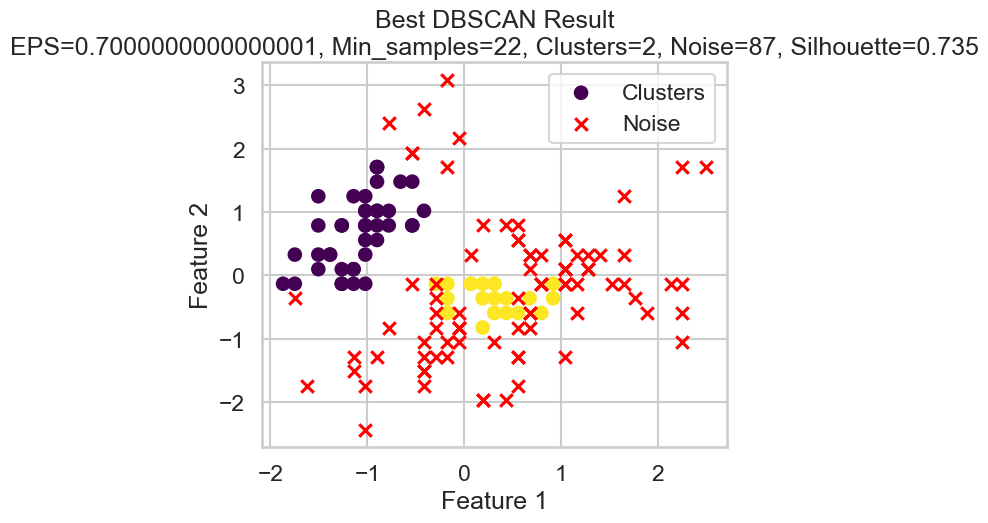

In [14]:
# DBSCAN Clustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

eps_values = np.arange(0.1, 3.1, 0.2)
min_samples_values = range(5, 26)

best_score = -1
best_params = None
best_labels = None
best_clusters = None
best_noise = None

results = []

for eps in eps_values:
    
    for min_s in min_samples_values:
        
        model = DBSCAN(eps=eps, min_samples=min_s)
        labels = model.fit_predict(X_scaled)
        
        # count clusters (exclude noise)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        # count noise
        n_noise = list(labels).count(-1)
        
        if n_clusters > 1:
            
            mask = labels != -1
            filtered_data = X_scaled[mask]
            filtered_labels = labels[mask]
            
            if len(set(filtered_labels)) > 1:
                
                score = silhouette_score(filtered_data, filtered_labels)
                
                print(f"EPS={eps:.2f} | Min_samples={min_s} | Clusters={n_clusters} | Noise={n_noise} | Silhouette={score:.3f}")
                
                results.append((eps, min_s, score))
                
                if score > best_score:
                    best_score = score
                    best_params = (eps, min_s)
                    best_labels = labels
                    best_clusters = n_clusters
                    best_noise = n_noise
            else:
                results.append((eps, min_s, np.nan))
        else:
            results.append((eps, min_s, np.nan))


print("\nBest DBSCAN Result")
print("Best EPS:", best_params[0])
print("Best Min_samples:", best_params[1])
print("Clusters Found:", best_clusters)
print("Noise Points:", best_noise)
print("Best Silhouette Score:", best_score)

best_dbscan_silhouette = best_score


# -------------------------------
# Plot Best Clustering
# -------------------------------

plt.figure(figsize=(6,5))

# cluster points
cluster_mask = best_labels != -1
plt.scatter(
    X_scaled[cluster_mask,0],
    X_scaled[cluster_mask,1],
    c=best_labels[cluster_mask],
    cmap='viridis',
    label="Clusters"
)

# noise points
noise_mask = best_labels == -1
plt.scatter(
    X_scaled[noise_mask,0],
    X_scaled[noise_mask,1],
    c='red',
    marker='x',
    label="Noise"
)

plt.title(
    f"Best DBSCAN Result\n"
    f"EPS={best_params[0]}, Min_samples={best_params[1]}, "
    f"Clusters={best_clusters}, Noise={best_noise}, "
    f"Silhouette={best_score:.3f}"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()

plt.show()

Metric=euclidean | Linkage=ward | Threshold=0.5 | Clusters=69 | Silhouette=0.278
Metric=euclidean | Linkage=ward | Threshold=1 | Clusters=35 | Silhouette=0.296
Metric=euclidean | Linkage=ward | Threshold=2 | Clusters=18 | Silhouette=0.309
Metric=euclidean | Linkage=ward | Threshold=3 | Clusters=11 | Silhouette=0.299
Metric=euclidean | Linkage=ward | Threshold=4 | Clusters=8 | Silhouette=0.311
Metric=euclidean | Linkage=complete | Threshold=0.5 | Clusters=70 | Silhouette=0.269
Metric=euclidean | Linkage=complete | Threshold=1 | Clusters=30 | Silhouette=0.276
Metric=euclidean | Linkage=complete | Threshold=2 | Clusters=11 | Silhouette=0.331
Metric=euclidean | Linkage=complete | Threshold=3 | Clusters=6 | Silhouette=0.311
Metric=euclidean | Linkage=complete | Threshold=4 | Clusters=4 | Silhouette=0.411
Metric=euclidean | Linkage=average | Threshold=0.5 | Clusters=55 | Silhouette=0.268
Metric=euclidean | Linkage=average | Threshold=1 | Clusters=17 | Silhouette=0.301
Metric=euclidean | Link

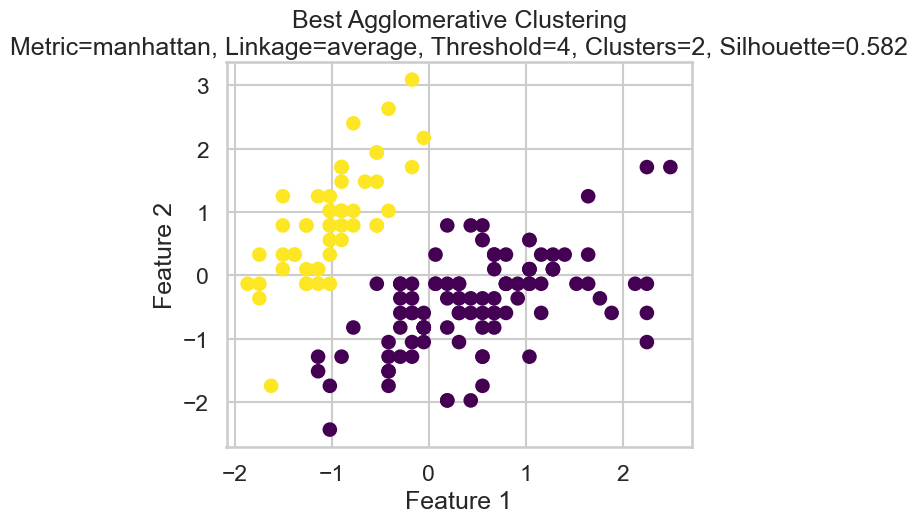

In [15]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']
distance_thresholds = [0.5, 1, 2, 3, 4]

best_score = -1
best_params = None
best_labels = None
best_clusters = None

results = []

for metric in metrics:
    
    for linkage in linkages:
        
        # Ward only works with Euclidean
        if linkage == 'ward' and metric != 'euclidean':
            continue
        
        for threshold in distance_thresholds:
            
            model = AgglomerativeClustering(
                n_clusters=None,
                metric=metric,
                linkage=linkage,
                distance_threshold=threshold
            )
            
            labels = model.fit_predict(X_scaled)
            
            n_clusters = len(np.unique(labels))
            
            if n_clusters > 1:
                
                score = silhouette_score(X_scaled, labels)
                
                print(f"Metric={metric} | Linkage={linkage} | Threshold={threshold} | Clusters={n_clusters} | Silhouette={score:.3f}")
                
                results.append((metric, linkage, threshold, score))
                
                if score > best_score:
                    best_score = score
                    best_params = (metric, linkage, threshold)
                    best_clusters = n_clusters
                    best_labels = labels
            else:
                results.append((metric, linkage, threshold, np.nan))


print("\nBest Agglomerative Result")
print("Metric:", best_params[0])
print("Linkage:", best_params[1])
print("Distance Threshold:", best_params[2])
print("Clusters Found:", best_clusters)
print("Best Silhouette Score:", best_score)

best_agglomerative_silhouette = best_score


# ---------------------------------
# Plot Best Clustering
# ---------------------------------

plt.figure(figsize=(6,5))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=best_labels,
    cmap='viridis'
)

plt.title(
    f"Best Agglomerative Clustering\n"
    f"Metric={best_params[0]}, Linkage={best_params[1]}, "
    f"Threshold={best_params[2]}, Clusters={best_clusters}, "
    f"Silhouette={best_score:.3f}"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [16]:
# Comparing all methods
print("Clustering Comparison\n")

print("KMeans Silhouette:", best_kmeans_silhouette)
print("Agglomerative Silhouette:", best_agglomerative_silhouette)
print("DBSCAN Silhouette:", best_dbscan_silhouette)

best_method = max([
    ("KMeans", best_kmeans_silhouette),
    ("Agglomerative", best_agglomerative_silhouette),
    ("DBSCAN", best_dbscan_silhouette)
], key=lambda x: x[1])

print("\nBest Overall Method:", best_method[0])
print("Best Score:", best_method[1])

Clustering Comparison

KMeans Silhouette: 0.5817500491982808
Agglomerative Silhouette: 0.5817500491982808
DBSCAN Silhouette: 0.7347920257635566

Best Overall Method: DBSCAN
Best Score: 0.7347920257635566


* Repeat all the above clustering approaches and steps on the above data.
* Comment on the effect of scaling on clustering this dataset. Show the difference between clustering the data with and without   scaling.
* Compare between the different clustering approaches.
* Is your clustering outcome consistent with the labels?

## Customer dataset
Repeat all the above on the customer data set

In [17]:
#Loading the dataset
path=r"C:\Users\smart\OneDrive\Documents\Semester 10\Machine Learning\Clustering Project\Clustering Project\Customer data.csv"
df = pd.read_csv(path, sep=",")

print(df.head())

          ID  Sex  Marital status  Age  Education  Income  Occupation  \
0  100000001    0               0   67          2  124670           1   
1  100000002    1               1   22          1  150773           1   
2  100000003    0               0   49          1   89210           0   
3  100000004    0               0   45          1  171565           1   
4  100000005    0               0   53          1  149031           1   

   Settlement size  
0                2  
1                2  
2                0  
3                1  
4                1  


### **Dataset Visulaization** 

In [18]:


# 1) Identify Numeric vs Categorical Features
print("Identifing Features!")
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("\n","Numeric:", numeric_cols)
print("\n","Categorical:", categorical_cols)


# 2) Missing data

import numpy as np

print( "\n","Missing Data:")
print(df.isnull().sum())


Identifing Features!

 Numeric: Index(['ID', 'Sex', 'Marital status', 'Age', 'Education', 'Income',
       'Occupation', 'Settlement size'],
      dtype='object')

 Categorical: Index([], dtype='object')

 Missing Data:
ID                 0
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64


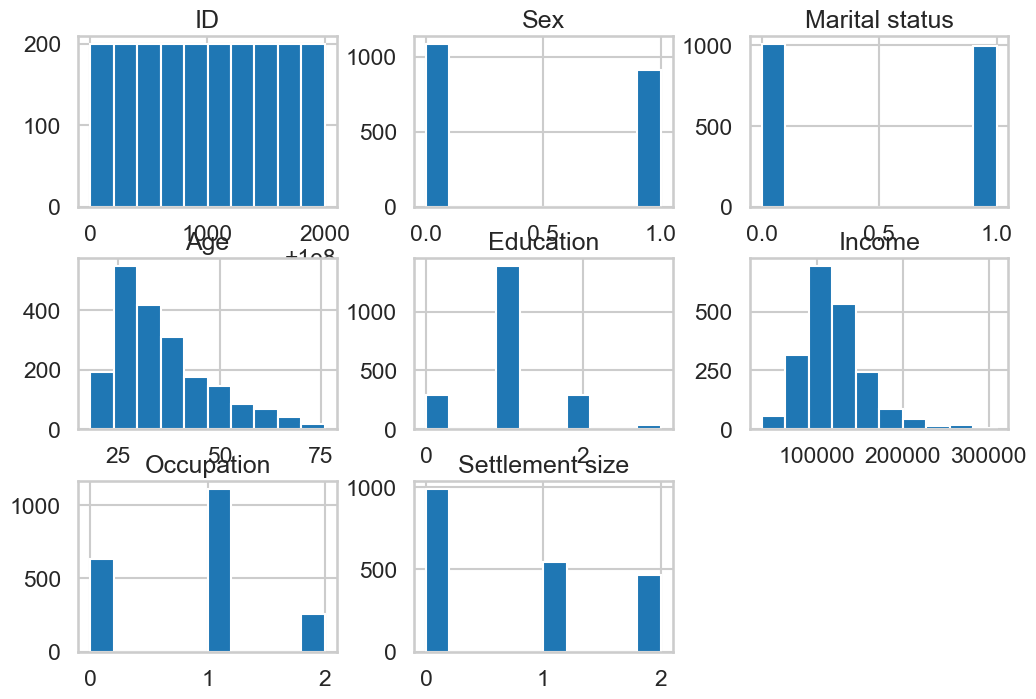

In [19]:
# 3) #Distribution of Numeric Features
df[numeric_cols].describe()
df[numeric_cols].skew()

import matplotlib.pyplot as plt

df[numeric_cols].hist(figsize=(12,8))
plt.show()

# Observations => Age and income show right-skewed distributions and require scaling before clustering

                       ID       Sex  Marital status       Age  Education  \
ID               1.000000  0.328262        0.074403 -0.085246   0.012543   
Sex              0.328262  1.000000        0.566511 -0.182885   0.244838   
Marital status   0.074403  0.566511        1.000000 -0.213178   0.374017   
Age             -0.085246 -0.182885       -0.213178  1.000000   0.654605   
Education        0.012543  0.244838        0.374017  0.654605   1.000000   
Income          -0.303217 -0.195146       -0.073528  0.340610   0.233459   
Occupation      -0.291958 -0.202491       -0.029490  0.108388   0.064524   
Settlement size -0.378445 -0.300803       -0.097041  0.119751   0.034732   

                   Income  Occupation  Settlement size  
ID              -0.303217   -0.291958        -0.378445  
Sex             -0.195146   -0.202491        -0.300803  
Marital status  -0.073528   -0.029490        -0.097041  
Age              0.340610    0.108388         0.119751  
Education        0.233459    0

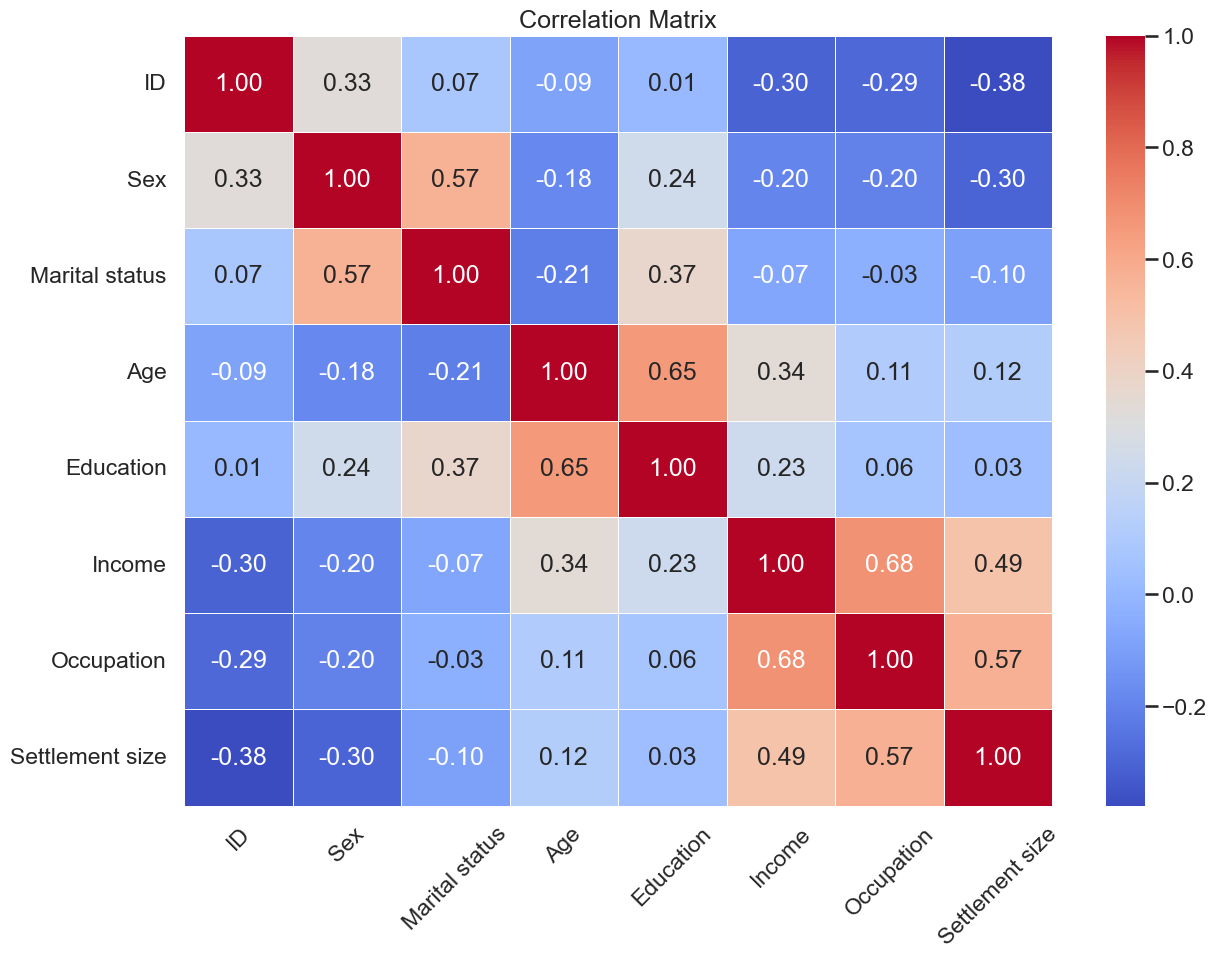

In [20]:
# 4) Correlation Between Numeric Features
corr = df[numeric_cols].corr()
print(corr)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), 
            annot=True, 
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Correlation Matrix")
plt.show()

# Observations => No extremely high correlations were observed. 
# Considering that, Income shows a strong positive correlation with occupation and Age also exhibits a positive correlation with education

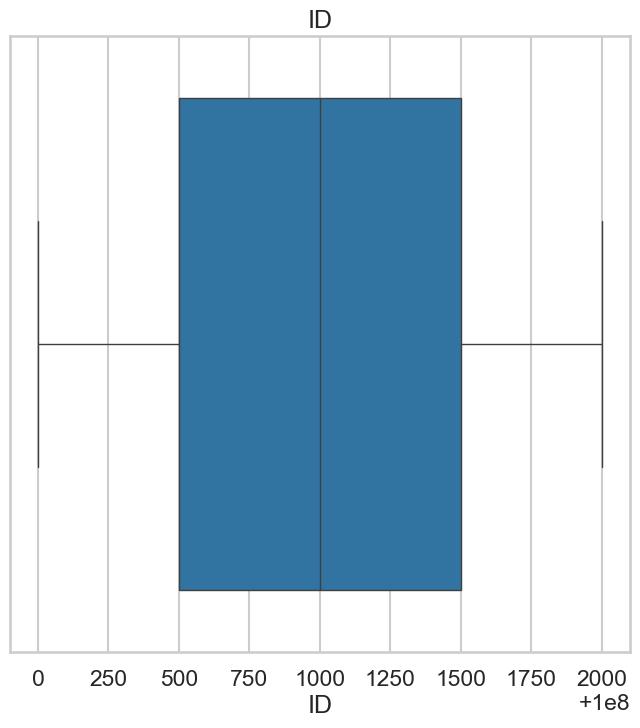

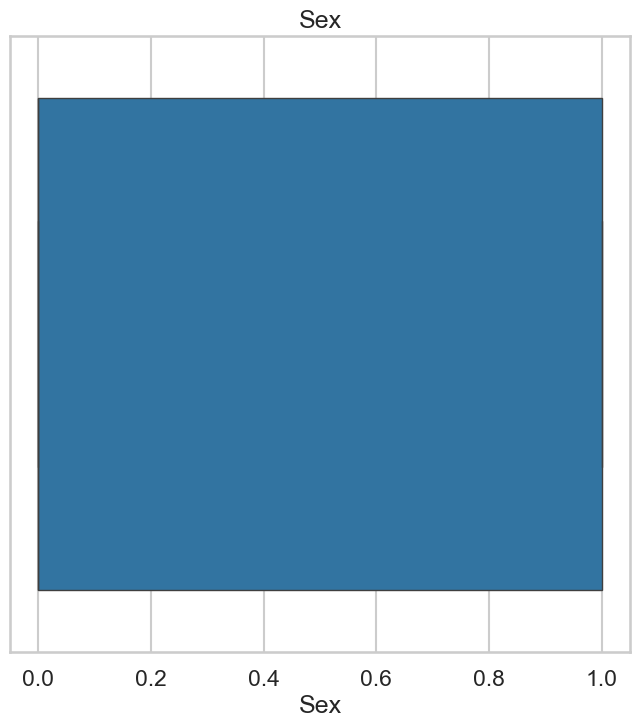

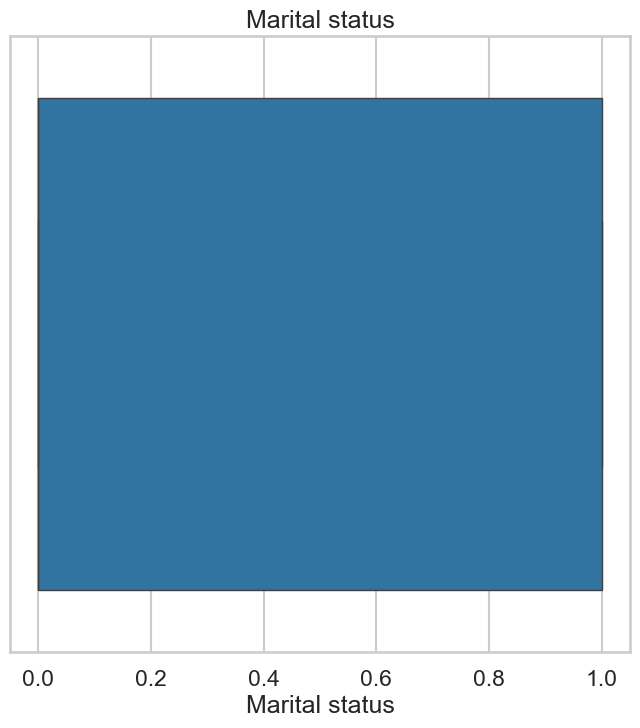

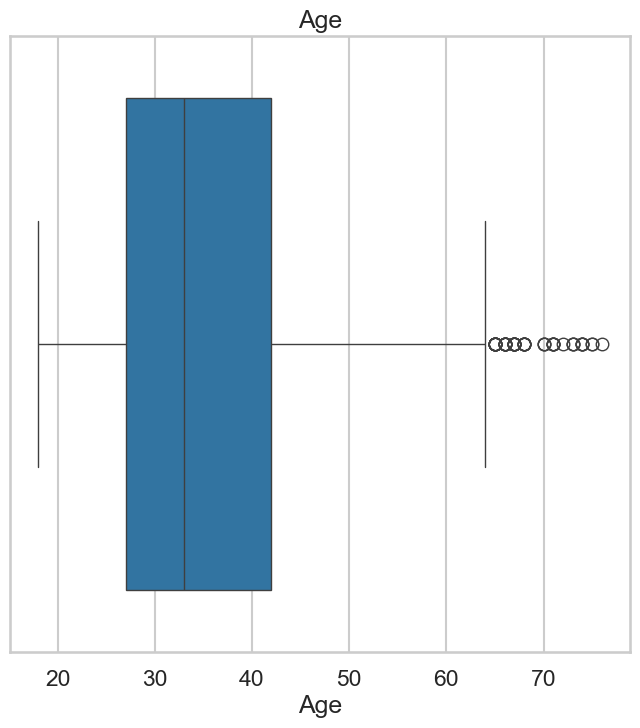

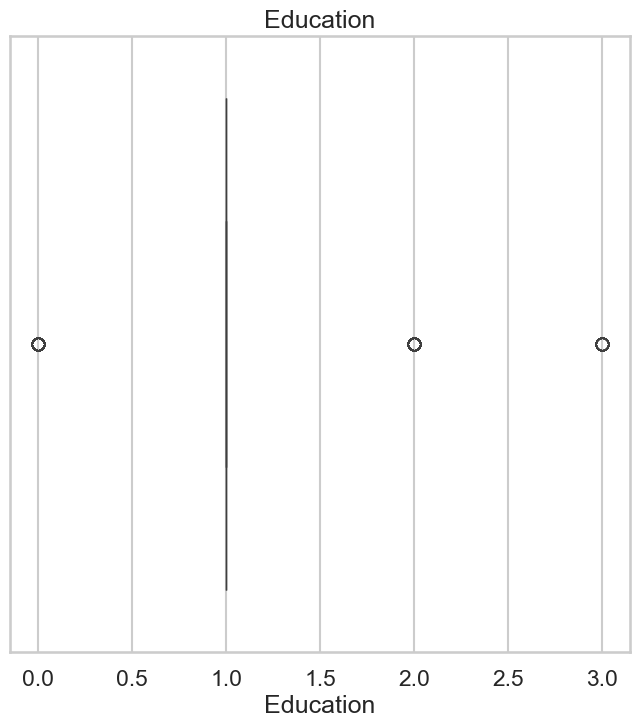

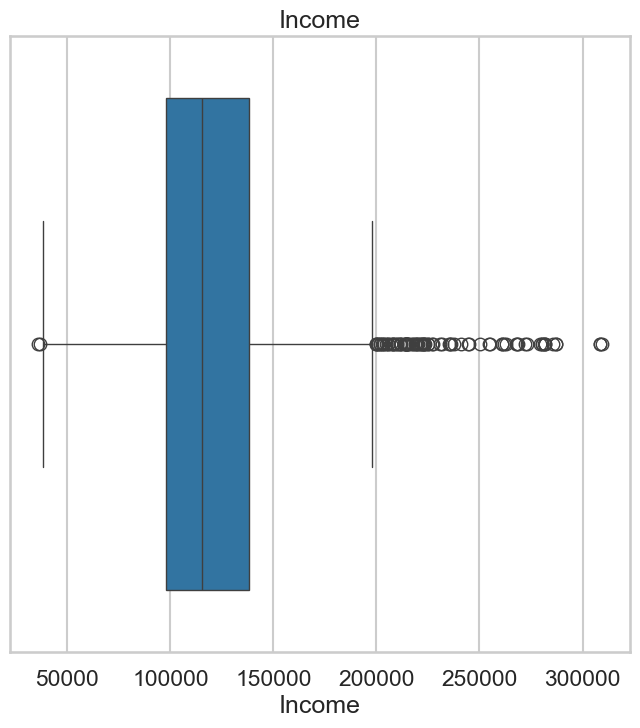

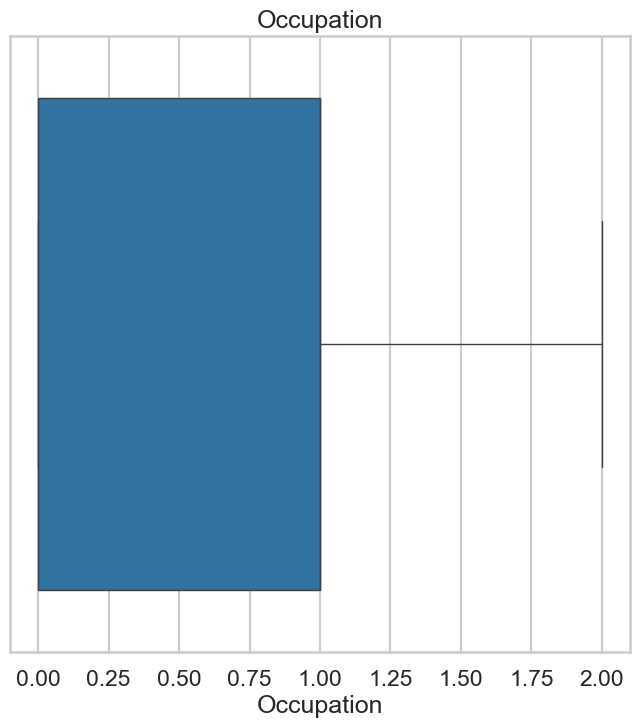

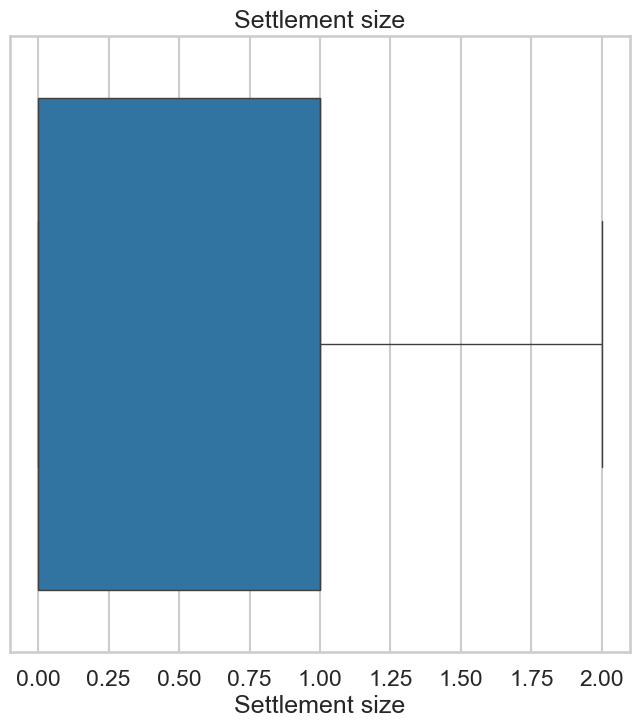

In [21]:
# 5) Outliers
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Observations => Age & Income features only shows some outliers which was expected from the skweness above.
# Also The education variable showed several apparent outliers due to its categorical nature, where values such as 0, 2, and 3 occur less frequently compared to the dominant category 1.    

### **Data Prepration** 

In [34]:
#Dropping
df_model = df.copy()

# drop the ids that has no meaning (C1001...)
df_model=df_model.drop("ID", axis=1)

#Encoding
print("No need for encoding as all features are already numerical!")

from sklearn.preprocessing import  StandardScaler

#Scaling
scaler = StandardScaler()
df_model[['Age','Income']] = scaler.fit_transform(df_model[['Age','Income']])

#df_model = pd.DataFrame(
 #   scaler.fit_transform(df_model),
  #  columns=df_model.columns
#)

#Final check on the dataset after data prepration
print("Missing values:", df_model.isnull().sum().sum())
print("Shape:", df_model.shape)
print("Data type:", type(df_model))

No need for encoding as all features are already numerical!
Missing values: 0
Shape: (2000, 7)
Data type: <class 'pandas.core.frame.DataFrame'>


### **Applying K-means Clustering** 

Rate of change in SSD: [-2314.47214493 -1070.76716353  -539.20927539  -405.50667769
  -331.45222923  -257.60356936  -202.83080683  -179.95606226
  -147.39552672]

Recommended number of clusters according to the Elbow Method: 2


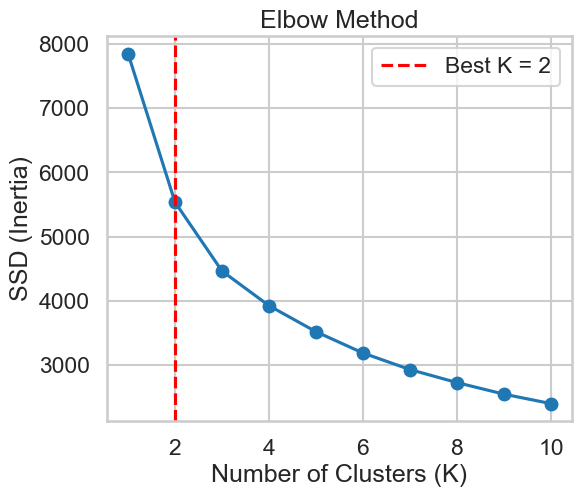


Best Clustering using KMeans
Best number of clusters: 2


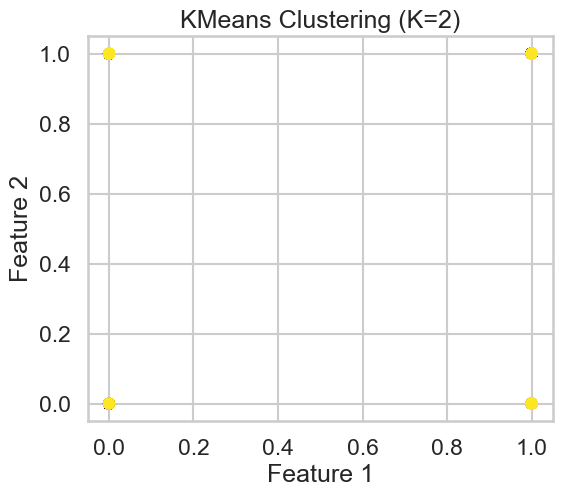

In [36]:
# Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

ssd = []
K_range = range(1,11)

# Compute SSD for each K
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_model)
    ssd.append(kmeans.inertia_)

# Compute rate of change
diffs = np.diff(ssd)

# Detect elbow
elbow_index = np.argmax(np.abs(diffs)) + 1
recommended_k = K_range[elbow_index]

print("Rate of change in SSD:", diffs)
print(f"\nRecommended number of clusters according to the Elbow Method: {recommended_k}")


# -----------------------------
# Plot Elbow Curve
# -----------------------------

plt.figure(figsize=(6,5))
plt.plot(K_range, ssd, marker='o')
plt.axvline(x=recommended_k, color='red', linestyle='--', label=f'Best K = {recommended_k}')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSD (Inertia)")
plt.title("Elbow Method")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# Fit KMeans using best K
# -----------------------------

best_kmeans = KMeans(n_clusters=recommended_k, random_state=42, n_init=10)
best_labels = best_kmeans.fit_predict(df_model)

print("\nBest Clustering using KMeans")
print("Best number of clusters:", recommended_k)


# -----------------------------
# Plot Best Clusters
# -----------------------------

plt.figure(figsize=(6,5))

plt.scatter(
    df_model.iloc[:,0],
    df_model.iloc[:,1],
    c=best_labels,
    cmap='viridis',
    s=50
)

plt.title(f"KMeans Clustering (K={recommended_k})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.grid(True)
plt.show()

K = 2, Silhouette Score = 0.3300
K = 3, Silhouette Score = 0.2482
K = 4, Silhouette Score = 0.2053
K = 5, Silhouette Score = 0.2167
K = 6, Silhouette Score = 0.2156
K = 7, Silhouette Score = 0.2266
K = 8, Silhouette Score = 0.2265
K = 9, Silhouette Score = 0.2320
K = 10, Silhouette Score = 0.2407

Recommended number of clusters according to Silhouette Method: 2


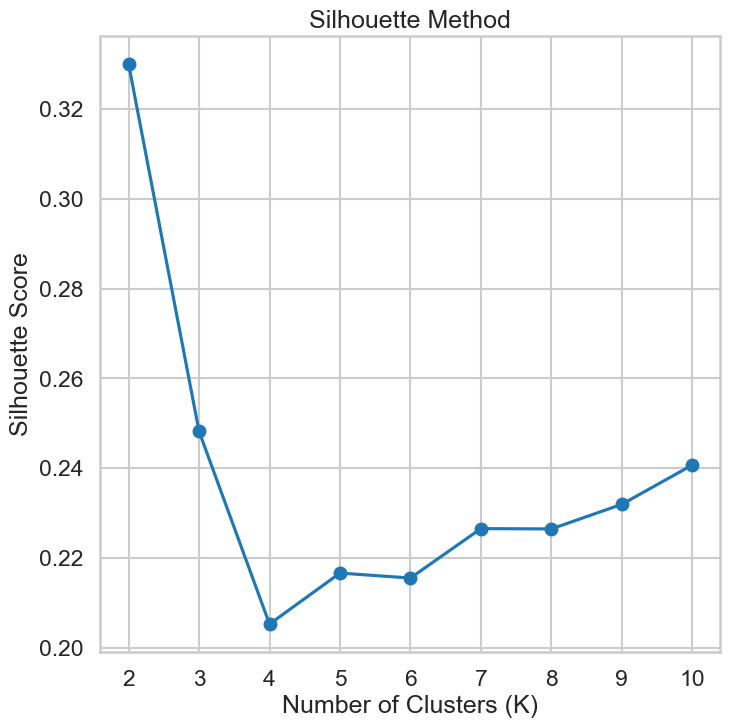

In [47]:
# Evaluating The Clustering Method Using: Silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []
K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_model)
    
    score = silhouette_score(df_model, labels)
    scores.append(score)
    
    # print silhouette score for each k
    print(f"K = {k}, Silhouette Score = {score:.4f}")

# find best k
best_k = K_range[scores.index(max(scores))]

print("\nRecommended number of clusters according to Silhouette Method:", best_k)

# plot
plt.plot(K_range, scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

best_kmeans_k = best_k
best_kmeans_silhouette = max(scores)

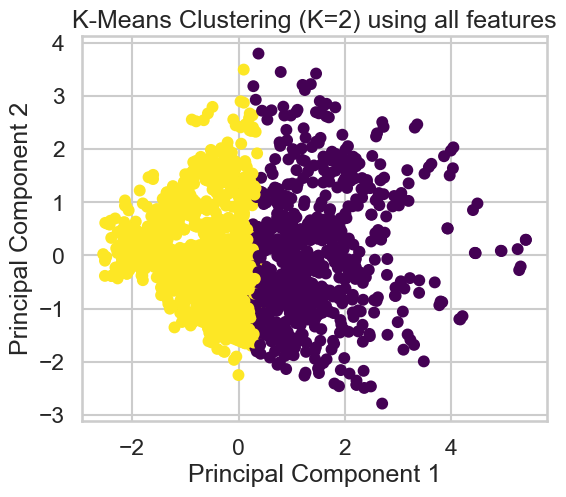

In [48]:
# Apply K=2
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(df_model)
df_model['Cluster'] = clusters

# Apply PCA to Reduce Dimensions
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_model.drop("Cluster", axis=1))

# Visualize Clusters Using PCA
plt.figure(figsize=(6,5))

plt.scatter(pca_data[:,0], pca_data[:,1],
            c=df_model['Cluster'], cmap='viridis', s=50)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering (K=2) using all features")

plt.show()


### **Applying DBSCAN Clustering** 

EPS=0.10 | Min_samples=5 | Clusters=39 | Noise=1542 | Silhouette=0.504
EPS=0.10 | Min_samples=6 | Clusters=30 | Noise=1624 | Silhouette=0.526
EPS=0.10 | Min_samples=7 | Clusters=22 | Noise=1739 | Silhouette=0.540
EPS=0.10 | Min_samples=8 | Clusters=14 | Noise=1820 | Silhouette=0.549
EPS=0.10 | Min_samples=9 | Clusters=9 | Noise=1890 | Silhouette=0.624
EPS=0.10 | Min_samples=10 | Clusters=8 | Noise=1918 | Silhouette=0.576
EPS=0.30 | Min_samples=5 | Clusters=48 | Noise=598 | Silhouette=0.458
EPS=0.30 | Min_samples=6 | Clusters=47 | Noise=659 | Silhouette=0.466
EPS=0.30 | Min_samples=7 | Clusters=38 | Noise=754 | Silhouette=0.486
EPS=0.30 | Min_samples=8 | Clusters=36 | Noise=812 | Silhouette=0.476
EPS=0.30 | Min_samples=9 | Clusters=28 | Noise=914 | Silhouette=0.504
EPS=0.30 | Min_samples=10 | Clusters=24 | Noise=1000 | Silhouette=0.514
EPS=0.30 | Min_samples=11 | Clusters=19 | Noise=1117 | Silhouette=0.525
EPS=0.30 | Min_samples=12 | Clusters=16 | Noise=1178 | Silhouette=0.543
EPS=0.30 

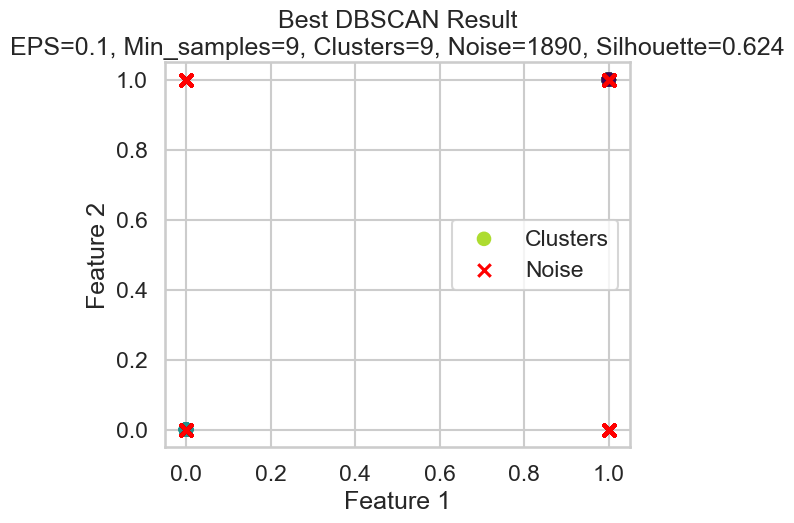

In [49]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# Parameter ranges required
eps_values = np.arange(0.1, 3.1, 0.2)
min_samples_values = range(5, 26)

best_score = -1
best_params = None
best_labels = None
best_clusters = None
best_noise = None

for eps in eps_values:
    
    for min_s in min_samples_values:
        
        model = DBSCAN(eps=eps, min_samples=min_s, metric='euclidean')
        labels = model.fit_predict(df_model)
        
        # count clusters
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters > 1:
            
            mask = labels != -1
            filtered_data = df_model[mask]
            filtered_labels = labels[mask]
            
            if len(set(filtered_labels)) > 1:
                
                score = silhouette_score(filtered_data, filtered_labels)
                
                print(f"EPS={eps:.2f} | Min_samples={min_s} | Clusters={n_clusters} | Noise={n_noise} | Silhouette={score:.3f}")
                
                if score > best_score:
                    best_score = score
                    best_params = (eps, min_s)
                    best_labels = labels
                    best_clusters = n_clusters
                    best_noise = n_noise


# -------------------------------
# Print best configuration safely
# -------------------------------

if best_params is not None:

    print("\nBest DBSCAN Result")
    print("Best EPS:", best_params[0])
    print("Best Min_samples:", best_params[1])
    print("Clusters Found:", best_clusters)
    print("Noise Points:", best_noise)
    print("Best Silhouette Score:", best_score)

else:
    print("No valid DBSCAN configuration found.")


# -------------------------------
# Plot Best Clustering
# -------------------------------

if best_labels is not None:

    X = np.array(df_model)  # works whether df_model is DataFrame or numpy

    plt.figure(figsize=(6,5))

    # cluster points
    cluster_mask = best_labels != -1
    plt.scatter(
        X[cluster_mask,0],
        X[cluster_mask,1],
        c=best_labels[cluster_mask],
        cmap='viridis',
        label="Clusters"
    )

    # noise points
    noise_mask = best_labels == -1
    plt.scatter(
        X[noise_mask,0],
        X[noise_mask,1],
        c='red',
        marker='x',
        label="Noise"
    )

    plt.title(
        f"Best DBSCAN Result\n"
        f"EPS={best_params[0]}, Min_samples={best_params[1]}, "
        f"Clusters={best_clusters}, Noise={best_noise}, "
        f"Silhouette={best_score:.3f}"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.legend()
    plt.grid(True)

    plt.show()

best_dbscan_params = best_params
best_dbscan_clusters = best_clusters
best_dbscan_noise = best_noise
best_dbscan_silhouette = best_score    

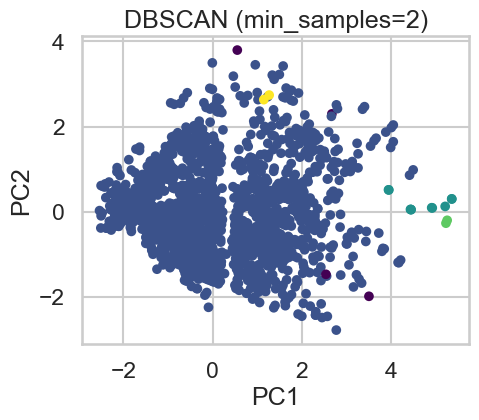

min_samples=2 → Clusters: 4, Noise: 4, Silhouette Score: 0.343


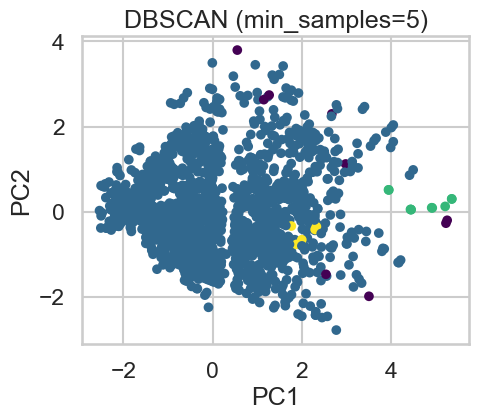

min_samples=5 → Clusters: 3, Noise: 9, Silhouette Score: 0.237


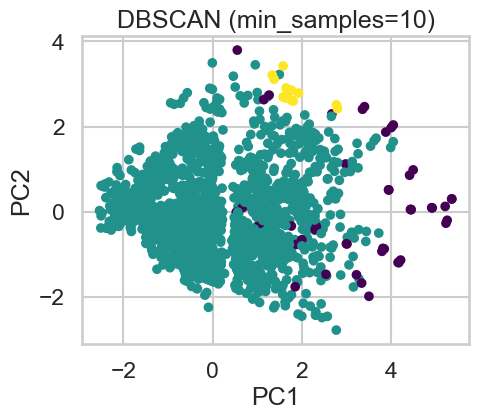

min_samples=10 → Clusters: 2, Noise: 45, Silhouette Score: 0.333


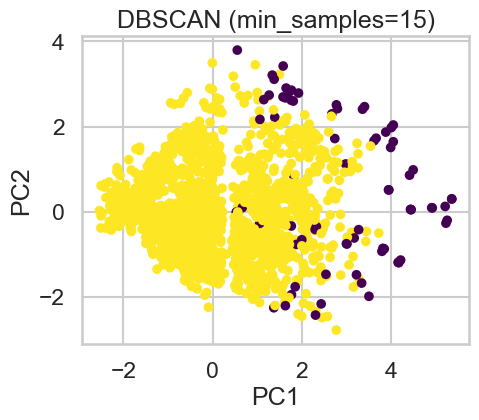

min_samples=15 → Too few clusters to compute silhouette score


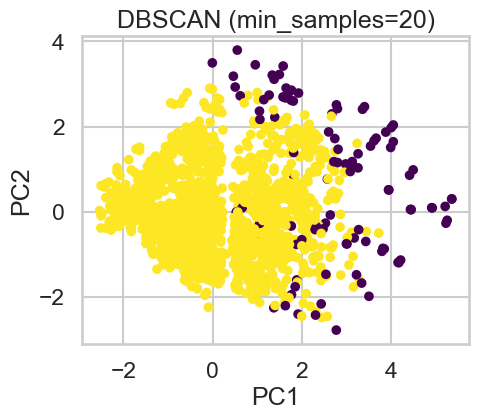

min_samples=20 → Too few clusters to compute silhouette score

 Best DBSCAN Configuration Found
Best EPS value: 0.1
Best Min_samples value: 9
Number of Clusters Found: 9
Number of Noise Points: 1890
Best Silhouette Score: 0.624


In [50]:
#Evaluating Using the Silhouette score to measure how good DBSCAN performed in different values including the sample above
# Reduce dimensionality for visualization ONLY
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_model)

min_samples_values = [2, 5, 10, 15, 20]

for min_samples in min_samples_values:
    
    # Apply DBSCAN
    dbscan = DBSCAN(eps=1.2, min_samples=min_samples)
    labels = dbscan.fit_predict(df_model)
    
    # ---- Visualization (PCA projection) ----
    plt.figure(figsize=(5,4))
    plt.scatter(X_pca[:,0], X_pca[:,1], 
                c=labels, cmap='viridis', s=30)
    plt.title(f"DBSCAN (min_samples={min_samples})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()
    
    # ---- Evaluation ----
    mask = labels != -1   # remove noise
    
    unique_clusters = set(labels[mask])
    
    if len(unique_clusters) > 1:
        score = silhouette_score(df_model[mask], labels[mask])
        print(f"min_samples={min_samples} → "
              f"Clusters: {len(unique_clusters)}, "
              f"Noise: {sum(labels==-1)}, "
              f"Silhouette Score: {score:.3f}")
    else:
        print(f"min_samples={min_samples} → "
              "Too few clusters to compute silhouette score")
        
print("\n===================================")
print(" Best DBSCAN Configuration Found")
print("===================================")

print(f"Best EPS value: {best_params[0]}")
print(f"Best Min_samples value: {best_params[1]}")
print(f"Number of Clusters Found: {best_clusters}")
print(f"Number of Noise Points: {best_noise}")
print(f"Best Silhouette Score: {best_score:.3f}")  




### **Applying Agglomerative Clustering** 

Metric=euclidean | Linkage=average | Threshold=3 | Clusters=6 | Silhouette=0.234
Metric=manhattan | Linkage=single | Threshold=2 | Clusters=6 | Silhouette=0.254
Metric=manhattan | Linkage=single | Threshold=3 | Clusters=2 | Silhouette=0.364
Metric=cosine | Linkage=complete | Threshold=1 | Clusters=8 | Silhouette=0.140
Metric=cosine | Linkage=average | Threshold=0.5 | Clusters=5 | Silhouette=0.116

 Best Agglomerative Configuration
Best Metric: manhattan
Best Linkage: single
Best Distance Threshold: 3
Clusters Found: 2
Best Silhouette Score: 0.364


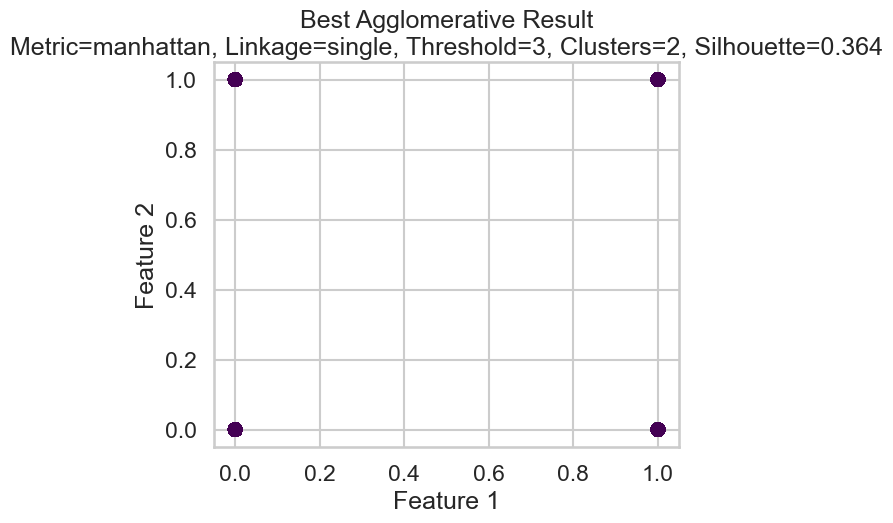

In [51]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']
distance_thresholds = [0.5, 1, 2, 3]

best_score = -1
best_params = None
best_labels = None
best_clusters = None

for metric in metrics:
    
    for linkage in linkages:
        
        # Ward only works with Euclidean
        if linkage == 'ward' and metric != 'euclidean':
            continue
        
        for threshold in distance_thresholds:
            
            model = AgglomerativeClustering(
                n_clusters=None,
                metric=metric,
                linkage=linkage,
                distance_threshold=threshold
            )
            
            labels = model.fit_predict(df_model)
            
            n_clusters = len(np.unique(labels))

            if n_clusters > 15:
                continue
            
            if n_clusters > 1:
                
                score = silhouette_score(df_model, labels)
                
                print(f"Metric={metric} | Linkage={linkage} | Threshold={threshold} | Clusters={n_clusters} | Silhouette={score:.3f}")
                
                if score > best_score:
                    best_score = score
                    best_params = (metric, linkage, threshold)
                    best_labels = labels
                    best_clusters = n_clusters


print("\n===================================")
print(" Best Agglomerative Configuration")
print("===================================")

print(f"Best Metric: {best_params[0]}")
print(f"Best Linkage: {best_params[1]}")
print(f"Best Distance Threshold: {best_params[2]}")
print(f"Clusters Found: {best_clusters}")
print(f"Best Silhouette Score: {best_score:.3f}")


# -------------------------------
# Plot Best Clustering
# -------------------------------

plt.figure(figsize=(6,5))

plt.scatter(
    df_model.iloc[:,0],
    df_model.iloc[:,1],
    c=best_labels,
    cmap='viridis',
)

plt.title(
    f"Best Agglomerative Result\n"
    f"Metric={best_params[0]}, Linkage={best_params[1]}, "
    f"Threshold={best_params[2]}, Clusters={best_clusters}, "
    f"Silhouette={best_score:.3f}"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

best_agglomerative_params = best_params
best_agglomerative_clusters = best_clusters
best_agglomerative_silhouette = best_score

# Observation => Even though your dataset has 2000 rows, many customers share the same binary combination, so all points overlap in the same 4 positions.

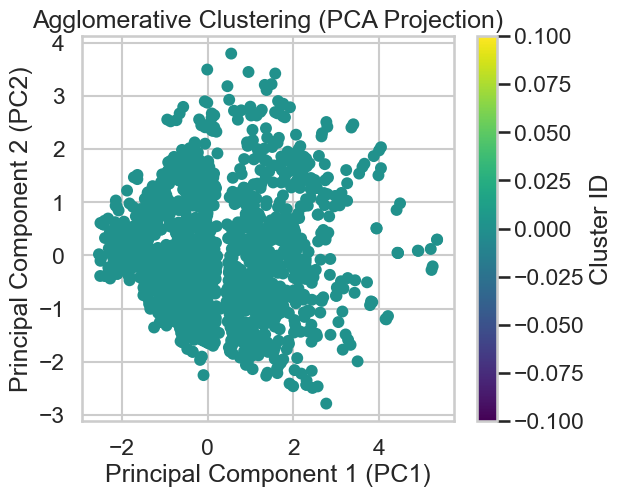

In [52]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_model)

# Plot PCA projection of clusters
plt.figure(figsize=(6,5))

scatter = plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=labels,
    cmap='viridis',
    s=50
)

plt.colorbar(scatter, label="Cluster ID")

plt.title("Agglomerative Clustering (PCA Projection)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")

plt.grid(True)
plt.show()

# Each dot = one customer.
# The location of a point depends on the combined values of all features.
# Customers with similar characteristics appear close together.

In [53]:
# Store best results from each method

# KMeans results
best_kmeans_k = best_k
best_kmeans_silhouette = max(scores)

# DBSCAN results
best_dbscan_params = best_params
best_dbscan_clusters = best_clusters
best_dbscan_noise = best_noise
best_dbscan_silhouette = best_score

# Agglomerative results
best_agglomerative_params = best_params
best_agglomerative_clusters = best_clusters
best_agglomerative_silhouette = best_score


print("\n======================================")
print(" Clustering Methods Comparison Summary")
print("======================================")

print(f"KMeans -> Best K: {best_kmeans_k}, "
      f"Silhouette Score: {best_kmeans_silhouette:.3f}")

print(f"DBSCAN -> EPS: {best_dbscan_params[0]}, "
      f"Min_samples: {best_dbscan_params[1]}, "
      f"Clusters: {best_dbscan_clusters}, "
      f"Noise: {best_dbscan_noise}, "
      f"Silhouette Score: {best_dbscan_silhouette:.3f}")

print(f"Agglomerative -> Metric: {best_agglomerative_params[0]}, "
      f"Linkage: {best_agglomerative_params[1]}, "
      f"Threshold: {best_agglomerative_params[2]}, "
      f"Clusters: {best_agglomerative_clusters}, "
      f"Silhouette Score: {best_agglomerative_silhouette:.3f}")


# Compare silhouette scores
method_scores = {
    "KMeans": best_kmeans_silhouette,
    "DBSCAN": best_dbscan_silhouette,
    "Agglomerative": best_agglomerative_silhouette
}

best_method = max(method_scores, key=method_scores.get)

print("\n======================================")
print(f"Best Clustering Method: {best_method}")
print(f"Best Silhouette Score: {method_scores[best_method]:.3f}")
print("======================================")


 Clustering Methods Comparison Summary
KMeans -> Best K: 2, Silhouette Score: 0.330
DBSCAN -> EPS: manhattan, Min_samples: single, Clusters: 2, Noise: 1890, Silhouette Score: 0.364
Agglomerative -> Metric: manhattan, Linkage: single, Threshold: 3, Clusters: 2, Silhouette Score: 0.364

Best Clustering Method: DBSCAN
Best Silhouette Score: 0.364
